<a href="https://www.kaggle.com/code/aamir28/climate-risk-extremes-190-capitals?scriptVersionId=324075023" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#000d1a;border-radius:16px;padding:0;font-family:'Courier New',monospace;border:1px solid #0ea5e9;overflow:hidden;margin:10px 0;">
  <div style="background:linear-gradient(90deg,#0ea5e9,#0284c7,#0369a1);padding:14px 28px;display:flex;align-items:center;gap:14px;">
    <span style="font-size:24px;">🛰️</span>
    <span style="font-size:1.1rem;font-weight:700;color:#fff;letter-spacing:2px;">NASA POWER · CLIMATE RISK TELEMETRY</span>
    <span style="margin-left:auto;font-size:0.8rem;color:#bae6fd;">DATASET v2024 · KAGGLE NOTEBOOK</span>
  </div>
  
  <div style="padding:28px 32px;">
    <div style="border:1px solid #0ea5e9;border-radius:8px;padding:18px 22px;margin-bottom:22px;background:#001529;">
      <div style="color:#38bdf8;font-size:0.75rem;letter-spacing:3px;margin-bottom:12px;">▶ MISSION BRIEF</div>
      <div style="color:#e0f2fe;font-size:0.9rem;line-height:1.8;">
        <span style="color:#0ea5e9;">SOURCE :</span> NASA POWER Climatology API + World Bank socioeconomic overlays<br>
        <span style="color:#0ea5e9;">SCOPE :</span> 190 national capitals · 35 years (1990–2024) · 55 climate + risk variables<br>
        <span style="color:#0ea5e9;">MISSION:</span> Quantify how planetary heating, drought, solar potential &amp; climate volatility are reshaping the risk profiles of the world's capital cities — and which nations face the most acute exposure in 2024.<br>
        <span style="color:#0ea5e9;">RECORDS:</span> 6,650 city-year observations · Panel data structure
      </div>
    </div>
    <div style="color:#38bdf8;font-size:0.75rem;letter-spacing:3px;margin-bottom:12px;">▶ LIVE TELEMETRY — 2024 SNAPSHOT</div>
    <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(240px,1fr));gap:12px;">
      <div style="background:#001529;border:1px solid #0369a1;border-radius:8px;padding:14px 18px;">
        <div style="color:#7dd3fc;font-size:0.75rem;letter-spacing:2px;margin-bottom:6px;">HOTTEST CAPITAL</div>
        <div style="color:#ef4444;font-size:1.4rem;font-weight:700;">30.1 °C</div>
        <div style="color:#475569;font-size:0.75rem;">Djibouti · 2024 annual mean</div>
      </div>
      <div style="background:#001529;border:1px solid #0369a1;border-radius:8px;padding:14px 18px;">
        <div style="color:#7dd3fc;font-size:0.75rem;letter-spacing:2px;margin-bottom:6px;">BIGGEST WARMER</div>
        <div style="color:#f59e0b;font-size:1.4rem;font-weight:700;">+2.87 °C</div>
        <div style="color:#475569;font-size:0.75rem;">Ankara · 34-year net gain</div>
      </div>
      <div style="background:#001529;border:1px solid #0369a1;border-radius:8px;padding:14px 18px;">
        <div style="color:#7dd3fc;font-size:0.75rem;letter-spacing:2px;margin-bottom:6px;">HIGHEST SOLAR YIELD</div>
        <div style="color:#fde047;font-size:1.4rem;font-weight:700;">1,095 kWh/m²</div>
        <div style="color:#475569;font-size:0.75rem;">Colombo · annual potential</div>
      </div>
      <div style="background:#001529;border:1px solid #0369a1;border-radius:8px;padding:14px 18px;">
        <div style="color:#7dd3fc;font-size:0.75rem;letter-spacing:2px;margin-bottom:6px;">MAX HEAT STRESS</div>
        <div style="color:#f97316;font-size:1.4rem;font-weight:700;">90 / 100</div>
        <div style="color:#475569;font-size:0.75rem;">Abu Dhabi · heat stress index</div>
      </div>
    </div>
    <div style="font-size:0.7rem;color:#1e3a5f;text-align:right;margin-top:15px;">
      AUTHOR: MUHAMMAD AAMIR
    </div>
  </div>
</div>

## 📡 Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview & EDA](#2)
3. [Feature Engineering](#3)
4. [Temperature Trends — 35-Year Warming Signal](#4)
5. [Extreme Heat Exposure — Days Above 35°C & 40°C](#5)
6. [Heat & Cold Stress Index Analysis](#6)
7. [Precipitation — Flood & Drought Risk](#7)
8. [Solar Potential — Renewable Energy Atlas](#8)
9. [Wind Power Density](#9)
10. [Ideal Climate Days — Liveability Index](#10)
11. [Climate Volatility by Income Group & Region](#11)
12. [GDP vs Climate Risk — The Vulnerability Trap](#12)
13. [Regional Risk Dashboard — 2024 Snapshot](#13)
14. [Correlation Heatmap](#14)
15. [Key Takeaways](#15)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Deep-navy / satellite theme ────────────────────────────────────────────────
BG, PANEL, GRID = '#000d1a', '#001529', '#0369a1'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor': PANEL,
    'axes.edgecolor':   GRID, 'axes.labelcolor': '#7dd3fc',
    'axes.titlecolor':  '#e0f2fe','axes.titlesize': 13,
    'axes.labelsize':   11,   'xtick.color': '#0ea5e9',
    'ytick.color':      '#0ea5e9', 'text.color': '#7dd3fc',
    'grid.color': '#0c2f4a',  'grid.linewidth': 0.55,
    'legend.facecolor': '#000d1a', 'legend.edgecolor': GRID,
    'font.family': 'DejaVu Sans',
})

# Colour system
HOT  = '#ef4444'   # extreme heat
WARM = '#f97316'   # warm / drought
COOL = '#38bdf8'   # cool / water
COLD = '#818cf8'   # cold stress
SUN  = '#fde047'   # solar
GRN  = '#34d399'   # ideal / green
PRP  = '#a78bfa'   # anomaly

CONT_PAL = {
    'Africa':'#f59e0b',      'Americas':'#34d399',
    'Europe':'#38bdf8',      'E.Mediterranean':'#f97316',
    'W.Pacific':'#a78bfa',   'SE Asia':'#ef4444',
    'Unknown':'#475569',
}
INCOME_PAL = {
    'High':'#34d399', 'UpperMid':'#38bdf8',
    'LowerMid':'#f59e0b', 'Low':'#ef4444', 'Unknown':'#475569',
}

CMAP_HEAT = LinearSegmentedColormap.from_list('heat', ['#000d1a','#f97316','#ef4444'])
CMAP_AQUA = LinearSegmentedColormap.from_list('aqua', ['#000d1a','#0ea5e9','#38bdf8'])
CMAP_DIV  = LinearSegmentedColormap.from_list('div',  ['#38bdf8','#000d1a','#ef4444'])
CMAP_SUN  = LinearSegmentedColormap.from_list('sun',  ['#000d1a','#fde047','#f59e0b'])

print('✅  Satellite theme active. Beginning telemetry analysis.')


✅  Satellite theme active. Beginning telemetry analysis.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/kanchana1990/nasa-power-climate-risk-and-extremes/nasa_power_climate_risk_indices_190_capitals_1990_2024.csv')

# Numeric coercion
num_cols = df.columns.difference(['city','iso_alpha3','continent','who_region','wb_income_group'])
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

print(f'Shape: {df.shape}')
print(f'Cities: {df.city.nunique()} | Years: {int(df.year.min())}–{int(df.year.max())}')
print(f'Continents: {df.continent.unique()}')
df.head(6)


Shape: (6650, 56)
Cities: 190 | Years: 1990–2024
Continents: ['E.Mediterranean' 'Africa' 'Europe' 'W.Pacific' 'Americas' 'SE Asia'
 'Unknown']


,city,iso_alpha3,latitude,longitude,continent,who_region,wb_income_group,year,data_days,temp_mean_c,...,solar_clearness_idx,solar_peak_days,solar_annual_kwh_m2,pressure_mean_kpa,pressure_std_kpa,climate_volatility,gdp_per_capita_usd,population,urban_pop_pct,energy_use_kg_oil_eq
0,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1990,365.0,27.695068,...,NaN,0.0,579.30,100.775370,0.801732,0.1810,26709.993440,1898220.0,78.685768,10740.842922
1,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1991,365.0,27.084274,...,NaN,0.0,556.38,100.800055,0.766893,0.0809,25690.968632,2006626.0,78.553863,11690.097020
2,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1992,366.0,26.680383,...,NaN,0.0,546.73,100.900656,0.778965,0.3512,25648.272776,2114730.0,78.441374,10562.899438
3,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1993,365.0,27.617425,...,NaN,0.0,571.01,100.864959,0.770028,0.5771,25032.782270,2222093.0,78.351924,10572.669831
4,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1994,365.0,27.643479,...,NaN,0.0,565.40,100.801123,0.834037,0.0204,25472.639658,2328188.0,78.289134,11178.398481
5,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1995,365.0,27.521068,...,NaN,0.0,563.66,100.822274,0.800524,0.6316,27003.200681,2434662.0,78.257808,11360.901471


## 2. Dataset Overview & EDA <a id='2'></a>


In [3]:
print('=== Data Types & Nulls ===')
df.info()
print('\n=== Missing Values (top 20) ===')
miss = df.isnull().sum().sort_values(ascending=False)
print(miss[miss>0].head(20))
print('\n=== Descriptive Statistics (selected) ===')
df[['temp_mean_c','days_above_35c','precip_total_mm','heat_stress_index',
    'ideal_climate_days','solar_annual_kwh_m2','climate_volatility']].describe().round(2)


=== Data Types & Nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 56 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   city                  6650 non-null   object 
 1   iso_alpha3            6650 non-null   object 
 2   latitude              6650 non-null   float64
 3   longitude             6650 non-null   float64
 4   continent             6650 non-null   object 
 5   who_region            6650 non-null   object 
 6   wb_income_group       6650 non-null   object 
 7   year                  6650 non-null   int64  
 8   data_days             6650 non-null   float64
 9   temp_mean_c           6650 non-null   float64
 10  temp_max_c            6650 non-null   float64
 11  temp_min_c            6650 non-null   float64
 12  temp_std_c            6650 non-null   float64
 13  temp_range_mean_c     6650 non-null   float64
 14  temp_seasonal_amp     6650 non-null   float64

,temp_mean_c,days_above_35c,precip_total_mm,heat_stress_index,ideal_climate_days,solar_annual_kwh_m2,climate_volatility
count,6650.00,6650.00,6650.00,6650.00,6650.00,6650.00,6650.00
mean,19.68,24.35,1027.81,2.02,48.27,489.72,1.57
std,7.56,50.67,784.48,8.81,50.70,108.85,2.20
min,-3.08,0.00,1.79,0.00,0.00,213.39,0.00
25%,13.22,0.00,507.58,0.00,6.00,423.24,0.25
50%,21.57,0.00,824.05,0.00,34.00,507.28,0.66
75%,26.56,20.00,1362.62,0.00,76.00,563.64,2.03
max,30.14,294.00,6989.14,95.00,311.00,1185.66,30.62


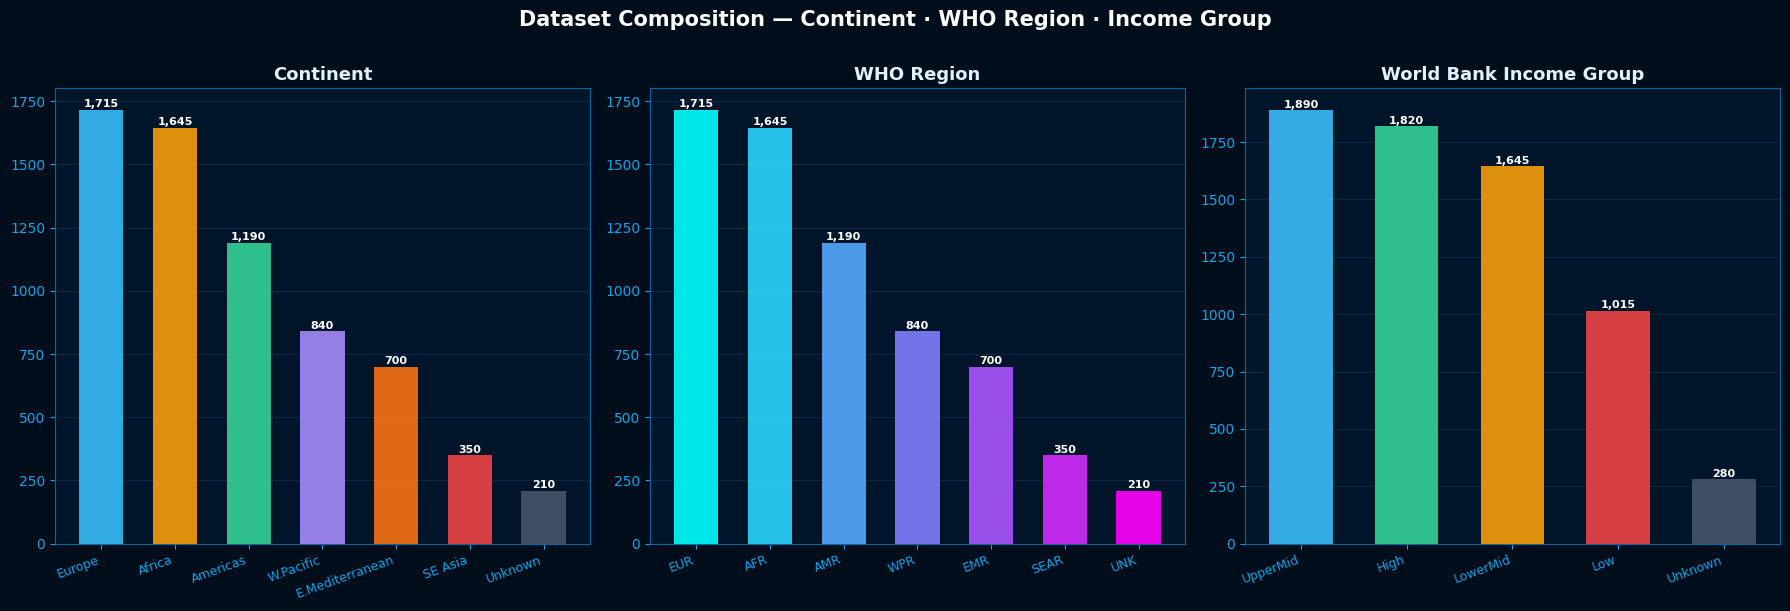

In [4]:
# Dataset composition
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Dataset Composition — Continent · WHO Region · Income Group',
             fontsize=15, fontweight='bold', color='white', y=1.01)

cats = [
    ('continent',      CONT_PAL,   'Continent'),
    ('who_region',     None,        'WHO Region'),
    ('wb_income_group',INCOME_PAL, 'World Bank Income Group'),
]
for ax, (col, pal, title) in zip(axes, cats):
    vc = df[col].value_counts()
    bar_cols = [pal.get(k,'#475569') for k in vc.index] if pal \
               else [plt.cm.cool(i/max(len(vc)-1,1)) for i in range(len(vc))]
    bars = ax.bar(range(len(vc)), vc.values, color=bar_cols,
                  width=0.6, zorder=3, edgecolor='none', alpha=0.9)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                f'{v:,}', ha='center', fontsize=8, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('01_composition.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 3. Feature Engineering <a id='3'></a>


In [5]:
# Combined risk index
df['heat_risk']      = df['days_above_35c'] / df['days_above_35c'].max() * 40 \
                     + df['heat_stress_index'] / df['heat_stress_index'].max() * 60
df['water_risk']     = df['drought_stress_days'] / df['drought_stress_days'].max() * 50 \
                     + (1 - df['precip_total_mm'].clip(0,2000) / 2000) * 50
df['composite_risk'] = df['heat_risk'] * 0.5 + df['water_risk'] * 0.3 \
                     + df['climate_volatility'] / df['climate_volatility'].max() * 20

# Climate zone classification by mean temp
df['climate_zone'] = pd.cut(df['temp_mean_c'],
                             bins=[-5, 5, 15, 22, 27, 35],
                             labels=['Polar/Cold','Temperate','Subtropical',
                                     'Tropical Warm','Tropical Hot'])

# Per-city warming rate (slope of temp over years)
warming_rates = (df.groupby('city')
                   .apply(lambda g: stats.linregress(g['year'].dropna(),
                                                     g['temp_mean_c'].dropna())[0])
                   .reset_index(name='warming_rate_per_yr'))
df = df.merge(warming_rates, on='city', how='left')

df24 = df[df['year']==2024].copy()
print(f'2024 snapshot: {len(df24)} cities')
print(f'Warming rate (°C/yr): mean={df24["warming_rate_per_yr"].mean():.4f}, '
      f'max={df24["warming_rate_per_yr"].max():.4f}')
df[['heat_risk','water_risk','composite_risk','climate_zone']].describe().round(3)


2024 snapshot: 190 cities
Warming rate (°C/yr): mean=0.0266, max=0.0732


,heat_risk,water_risk,composite_risk
count,6650.000,6650.000,6650.000
mean,4.590,33.946,13.502
std,10.283,20.785,9.986
min,0.000,0.000,0.046
25%,0.000,20.072,7.421
50%,0.000,33.141,12.037
75%,3.158,46.265,16.554
max,80.408,97.196,65.095


## 4. Temperature Trends — 35-Year Warming Signal <a id='4'></a>


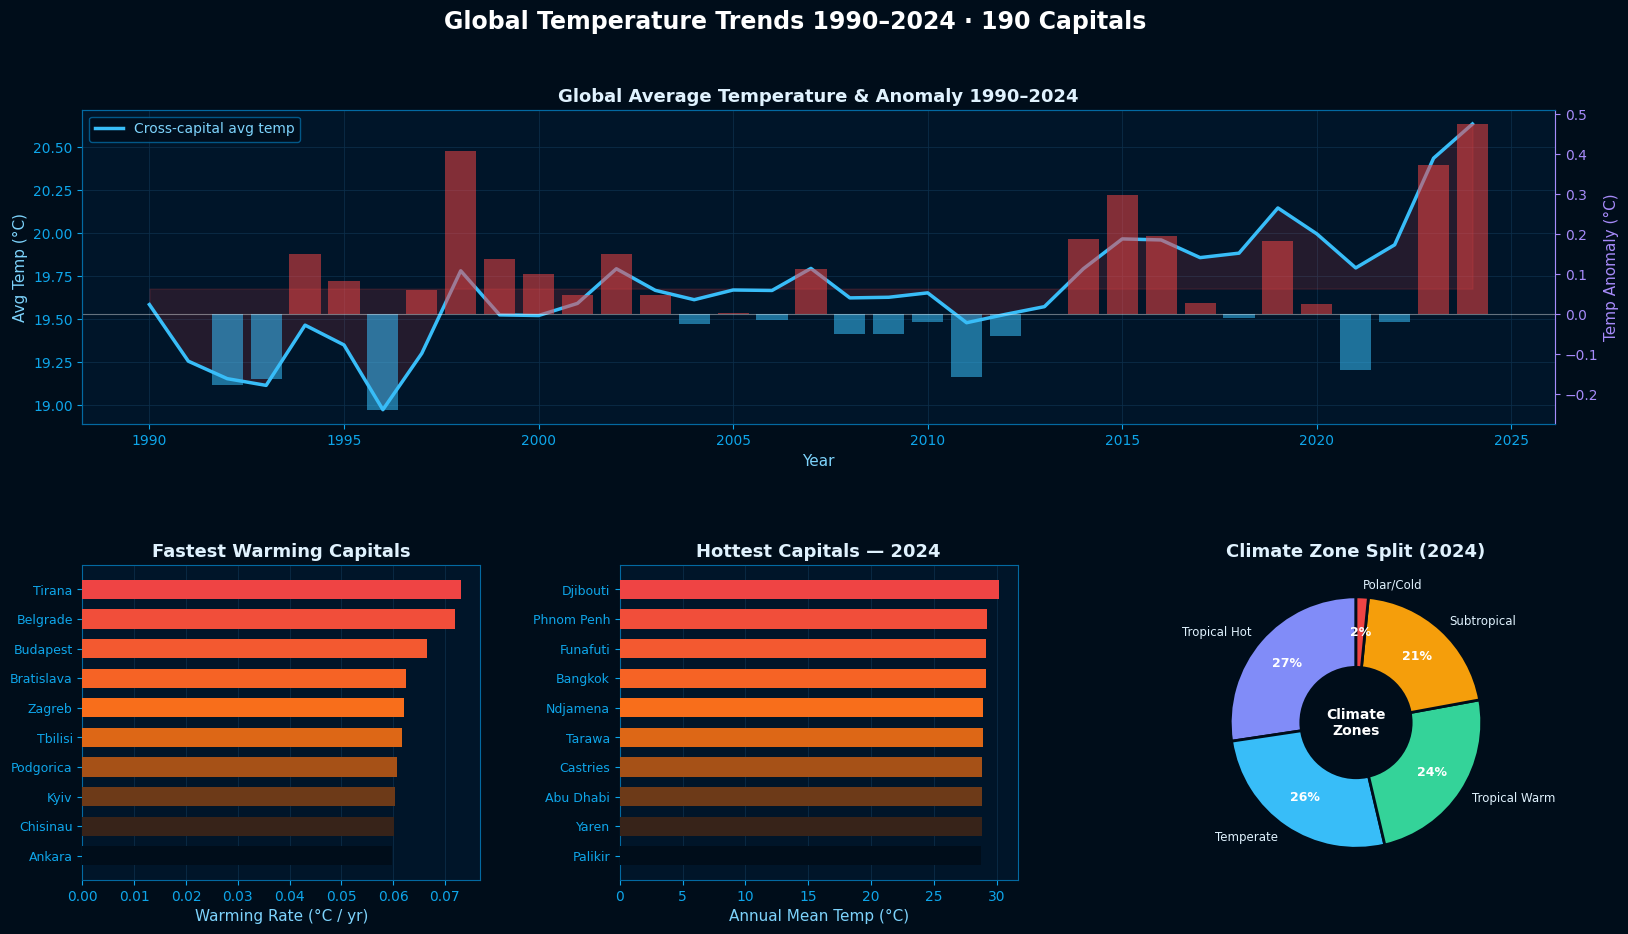

In [6]:
fig = plt.figure(figsize=(19, 10), facecolor=BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Global Temperature Trends 1990–2024 · 190 Capitals',
             fontsize=17, fontweight='bold', color='white')

# 1. Global avg temp line + anomaly fill (top full row)
ax = fig.add_subplot(gs[0, :])
ax.set_facecolor(PANEL)
yr_avg = df.groupby('year')['temp_mean_c'].mean()
yr_anom = df.groupby('year')['temp_anomaly'].mean()
ax.fill_between(yr_avg.index, yr_avg.values,
                yr_avg.values.mean(), alpha=0.15, color=HOT)
ax.plot(yr_avg.index, yr_avg.values, color=COOL, lw=2.5, zorder=5,
        label='Cross-capital avg temp')
ax2 = ax.twinx()
ax2.bar(yr_anom.index, yr_anom.values,
        color=[HOT if v>0 else COOL for v in yr_anom.values],
        alpha=0.55, label='Temp anomaly')
ax2.axhline(0, color='white', lw=0.8, alpha=0.4)
ax2.set_ylabel('Temp Anomaly (°C)', color=PRP)
ax2.tick_params(axis='y', colors=PRP)
ax2.spines['right'].set_color(PRP)
ax.set_xlabel('Year'); ax.set_ylabel('Avg Temp (°C)')
ax.set_title('Global Average Temperature & Anomaly 1990–2024', fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Top 10 warming cities
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(PANEL)
top_warm = df24.nlargest(10,'warming_rate_per_yr')[['city','warming_rate_per_yr']]
colors_w = [CMAP_HEAT(i/9) for i in range(10)]
ax3.barh(range(10), top_warm['warming_rate_per_yr'].values[::-1],
          color=colors_w, height=0.65, zorder=3, edgecolor='none')
ax3.set_yticks(range(10))
ax3.set_yticklabels(top_warm['city'].values[::-1], fontsize=9)
ax3.set_xlabel('Warming Rate (°C / yr)')
ax3.set_title('Fastest Warming Capitals', fontweight='bold')
ax3.grid(axis='x', zorder=0); ax3.set_axisbelow(True)

# 3. Hottest 2024
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(PANEL)
hot10 = df24.nlargest(10,'temp_mean_c')[['city','temp_mean_c']]
colors_h = [CMAP_HEAT(i/9) for i in range(10)]
ax4.barh(range(10), hot10['temp_mean_c'].values[::-1],
          color=colors_h, height=0.65, zorder=3, edgecolor='none')
ax4.set_yticks(range(10))
ax4.set_yticklabels(hot10['city'].values[::-1], fontsize=9)
ax4.set_xlabel('Annual Mean Temp (°C)')
ax4.set_title('Hottest Capitals — 2024', fontweight='bold')
ax4.grid(axis='x', zorder=0); ax4.set_axisbelow(True)

# 4. Climate zone distribution
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(PANEL)
zones = df24['climate_zone'].value_counts()
zone_cols = ['#818cf8','#38bdf8','#34d399','#f59e0b','#ef4444']
wedges, texts, ats = ax5.pie(
    zones.values, labels=zones.index, colors=zone_cols[:len(zones)],
    autopct='%1.0f%%', startangle=90, pctdistance=0.72,
    wedgeprops=dict(linewidth=2, edgecolor='#000d1a'),
    textprops=dict(fontsize=8.5, color='#e0f2fe'))
for at in ats: at.set_color('white'); at.set_fontsize(9); at.set_fontweight('bold')
centre = plt.Circle((0,0), 0.45, fc='#000d1a')
ax5.add_patch(centre)
ax5.text(0,0,'Climate\nZones', ha='center', va='center',
          fontsize=10, fontweight='bold', color='white')
ax5.set_title('Climate Zone Split (2024)', fontweight='bold')

plt.savefig('02_temp_trends.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


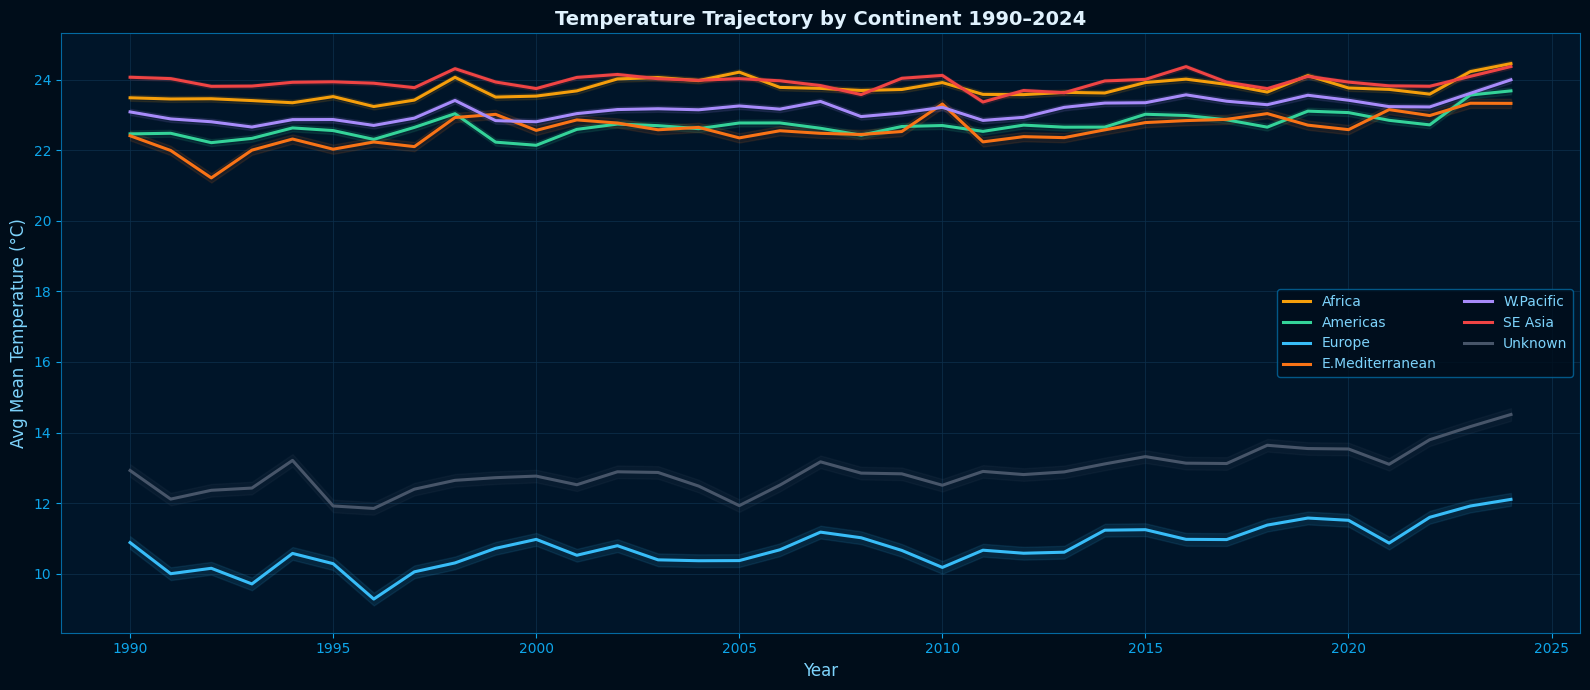

In [7]:
# Continental temperature trajectories
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)

for cont, color in CONT_PAL.items():
    sub = df[df['continent']==cont].groupby('year')['temp_mean_c'].mean()
    if len(sub) > 5:
        ax.fill_between(sub.index, sub - sub.std() * 0.3, sub + sub.std() * 0.3,
                         alpha=0.10, color=color)
        ax.plot(sub.index, sub, color=color, lw=2.2,
                label=cont, zorder=5)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg Mean Temperature (°C)', fontsize=12)
ax.set_title('Temperature Trajectory by Continent 1990–2024', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_continental_temps.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 5. Extreme Heat Exposure — Days Above 35°C & 40°C <a id='5'></a>


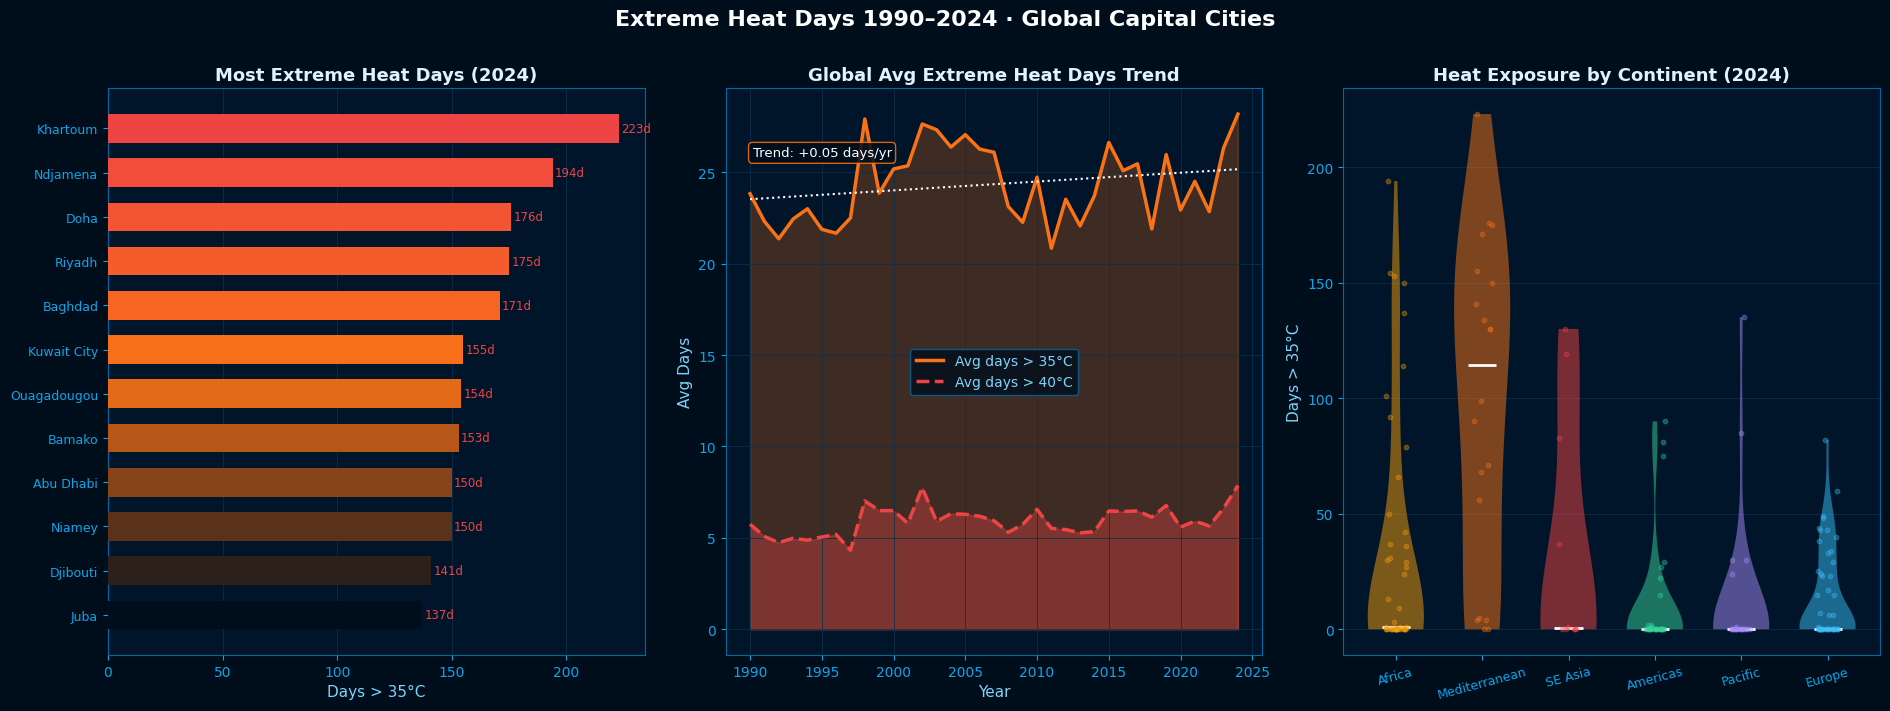

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Extreme Heat Days 1990–2024 · Global Capital Cities',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Top 12 cities days above 35C in 2024
ax = axes[0]
top35 = df24.nlargest(12, 'days_above_35c')[['city','days_above_35c']]
colors_t = [CMAP_HEAT(i/11) for i in range(12)]
ax.barh(range(12), top35['days_above_35c'].values[::-1],
         color=colors_t, height=0.65, zorder=3, edgecolor='none')
ax.set_yticks(range(12))
ax.set_yticklabels(top35['city'].values[::-1], fontsize=9)
ax.set_xlabel('Days > 35°C')
ax.set_title('Most Extreme Heat Days (2024)', fontweight='bold')
for i, v in enumerate(top35['days_above_35c'].values[::-1]):
    ax.text(v+1, i, f'{int(v)}d', va='center', fontsize=8.5, color=HOT)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Global trend: avg days above 35C by year
ax = axes[1]
yr35 = df.groupby('year')['days_above_35c'].mean()
yr40 = df.groupby('year')['days_above_40c'].mean()
ax.fill_between(yr35.index, yr35.values, alpha=0.25, color=WARM)
ax.fill_between(yr40.index, yr40.values, alpha=0.35, color=HOT)
ax.plot(yr35.index, yr35.values, color=WARM, lw=2.5, label='Avg days > 35°C')
ax.plot(yr40.index, yr40.values, color=HOT,  lw=2.5, label='Avg days > 40°C', ls='--')
m35, b35, r35, p35, _ = stats.linregress(yr35.index, yr35.values)
ax.plot(yr35.index, m35*yr35.index + b35, color='white', lw=1.5, ls=':')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Days')
ax.set_title('Global Avg Extreme Heat Days Trend', fontweight='bold')
ax.legend(fontsize=10)
ax.annotate(f'Trend: {m35:+.2f} days/yr',
             xy=(0.05,0.88), xycoords='axes fraction',
             fontsize=9.5, color='white',
             bbox=dict(boxstyle='round', facecolor='#000d1a', edgecolor=WARM, alpha=0.85))
ax.grid(True, zorder=0)

# 3. Heat days by continent (violin)
ax = axes[2]
conts_order = ['Africa','E.Mediterranean','SE Asia','Americas','W.Pacific','Europe']
for i, (cont, color) in enumerate([(c, CONT_PAL.get(c,'#475569')) for c in conts_order]):
    data = df24[df24['continent']==cont]['days_above_35c'].dropna()
    if len(data) > 2:
        vp = ax.violinplot(data, positions=[i], widths=0.65,
                           showmedians=True, showextrema=False)
        for pc in vp['bodies']: pc.set_facecolor(color); pc.set_alpha(0.5)
        vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
        jitter = np.random.uniform(-0.12, 0.12, len(data))
        ax.scatter(i+jitter, data, s=10, alpha=0.35, color=color, zorder=4)
ax.set_xticks(range(len(conts_order)))
ax.set_xticklabels([c.split('.')[1] if '.' in c else c
                    for c in conts_order], fontsize=9, rotation=15)
ax.set_ylabel('Days > 35°C')
ax.set_title('Heat Exposure by Continent (2024)', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_extreme_heat.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. Heat & Cold Stress Index Analysis <a id='6'></a>


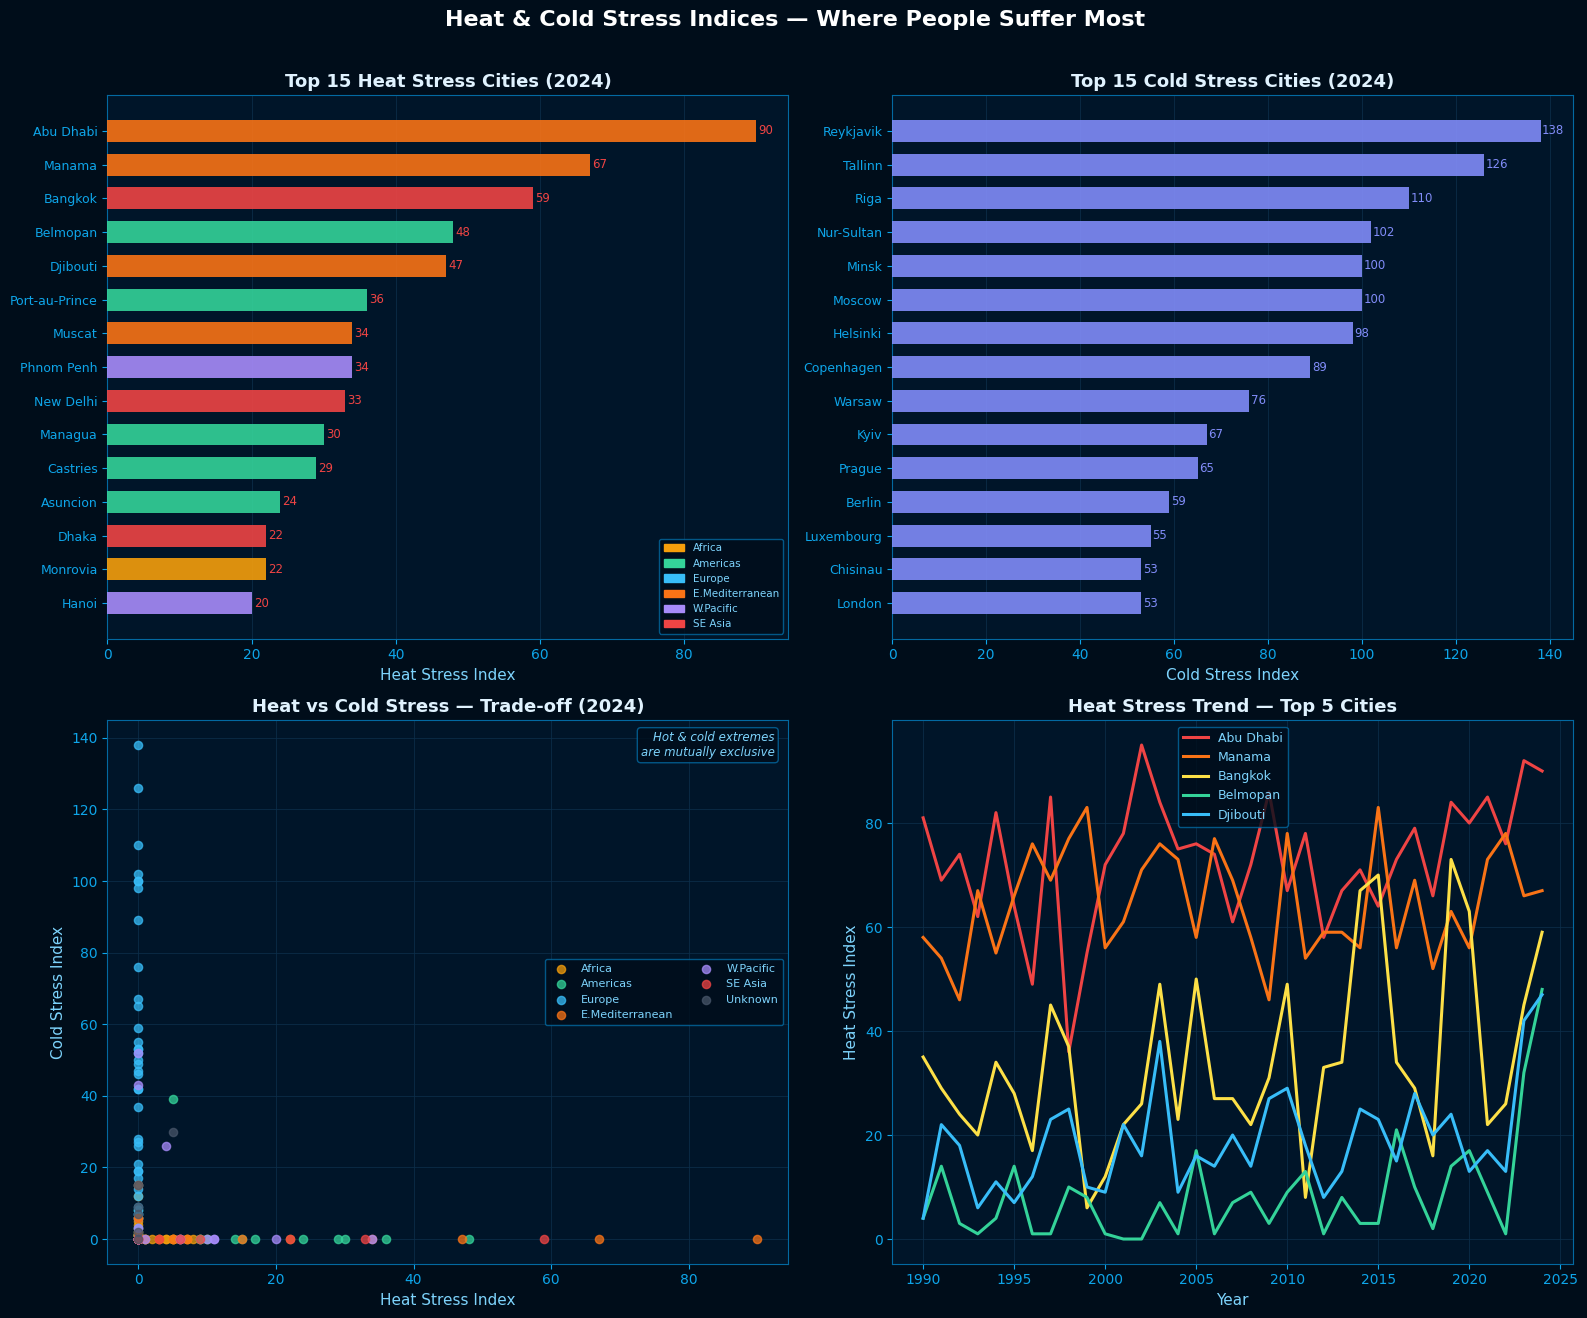

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.patch.set_facecolor(BG)
fig.suptitle('Heat & Cold Stress Indices — Where People Suffer Most',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Top 15 heat stress (2024)
ax = axes[0,0]
hs = df24.nlargest(15,'heat_stress_index')[['city','heat_stress_index','continent']]
bar_cols = [CONT_PAL.get(c,'#475569') for c in hs['continent']]
bars = ax.barh(range(15), hs['heat_stress_index'].values[::-1],
               color=bar_cols[::-1], height=0.65, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(15))
ax.set_yticklabels(hs['city'].values[::-1], fontsize=9)
ax.set_xlabel('Heat Stress Index')
ax.set_title('Top 15 Heat Stress Cities (2024)', fontweight='bold')
for i, v in enumerate(hs['heat_stress_index'].values[::-1]):
    ax.text(v+0.3, i, f'{v:.0f}', va='center', fontsize=8.5, color=HOT)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
# Colour legend
patches = [mpatches.Patch(color=c, label=r) for r,c in CONT_PAL.items() if r!='Unknown']
ax.legend(handles=patches, fontsize=7.5, loc='lower right')

# 2. Top 15 cold stress (2024)
ax = axes[0,1]
cs = df24.nlargest(15,'cold_stress_index')[['city','cold_stress_index','continent']]
bar_cols2 = [COLD if c=='Europe' else '#38bdf8' for c in cs['continent']]
ax.barh(range(15), cs['cold_stress_index'].values[::-1],
         color=bar_cols2[::-1], height=0.65, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(15))
ax.set_yticklabels(cs['city'].values[::-1], fontsize=9)
ax.set_xlabel('Cold Stress Index')
ax.set_title('Top 15 Cold Stress Cities (2024)', fontweight='bold')
for i, v in enumerate(cs['cold_stress_index'].values[::-1]):
    ax.text(v+0.3, i, f'{v:.0f}', va='center', fontsize=8.5, color=COLD)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 3. Heat vs cold stress scatter
ax = axes[1,0]
for cont, color in CONT_PAL.items():
    sub = df24[df24['continent']==cont]
    ax.scatter(sub['heat_stress_index'], sub['cold_stress_index'],
               color=color, s=35, alpha=0.75, label=cont, zorder=4)
ax.set_xlabel('Heat Stress Index')
ax.set_ylabel('Cold Stress Index')
ax.set_title('Heat vs Cold Stress — Trade-off (2024)', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, zorder=0); ax.set_axisbelow(True)
ax.text(0.98,0.98,'Hot & cold extremes\nare mutually exclusive',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
        color='#7dd3fc', style='italic',
        bbox=dict(boxstyle='round', facecolor='#000d1a', edgecolor=GRID, alpha=0.8))

# 4. Heat stress trend: top 5 cities over time
ax = axes[1,1]
top5_heat = df24.nlargest(5,'heat_stress_index')['city'].tolist()
c5_cols = [HOT, WARM, '#fde047', GRN, COOL]
for city, col in zip(top5_heat, c5_cols):
    sub = df[df['city']==city].sort_values('year')
    ax.plot(sub['year'], sub['heat_stress_index'], color=col,
             lw=2.2, label=city, zorder=5)
ax.set_xlabel('Year'); ax.set_ylabel('Heat Stress Index')
ax.set_title('Heat Stress Trend — Top 5 Cities', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('05_stress_indices.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Precipitation — Flood & Drought Risk <a id='7'></a>


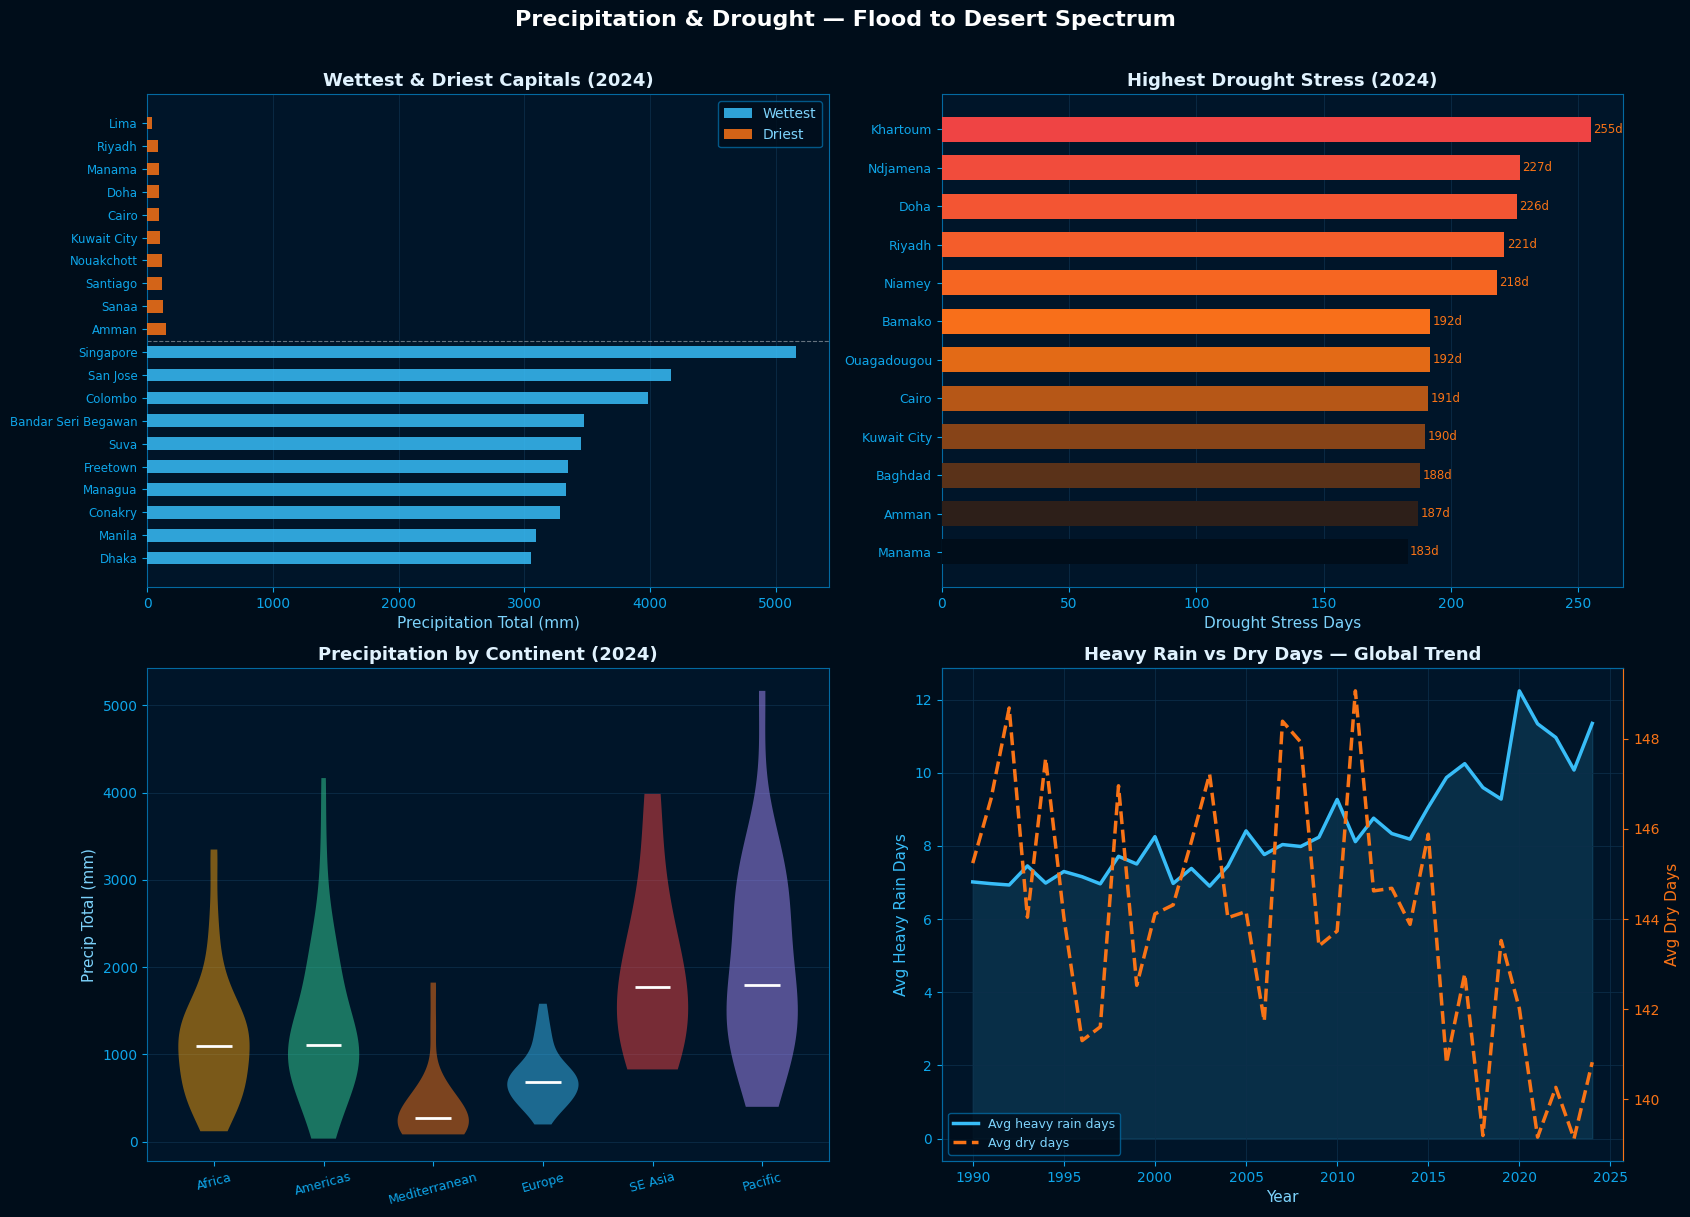

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
fig.patch.set_facecolor(BG)
fig.suptitle('Precipitation & Drought — Flood to Desert Spectrum',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Wettest vs driest 2024
ax = axes[0,0]
wet10 = df24.nlargest(10,'precip_total_mm')[['city','precip_total_mm']]
dry10 = df24.nsmallest(10,'precip_total_mm')[['city','precip_total_mm']]
ax.barh(range(10), wet10['precip_total_mm'].values[::-1],
         color=COOL, height=0.55, alpha=0.85, label='Wettest', zorder=3)
ax.barh(range(10,20), dry10['precip_total_mm'].values[::-1],
         color=WARM, height=0.55, alpha=0.85, label='Driest', zorder=3)
ax.set_yticks(list(range(10))+list(range(10,20)))
ax.set_yticklabels(list(wet10['city'].values[::-1])+list(dry10['city'].values[::-1]),
                    fontsize=8.5)
ax.axhline(9.5, color='white', lw=0.8, ls='--', alpha=0.4)
ax.set_xlabel('Precipitation Total (mm)')
ax.set_title('Wettest & Driest Capitals (2024)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Drought stress days top 12
ax = axes[0,1]
drs = df24.nlargest(12,'drought_stress_days')[['city','drought_stress_days']]
cols_d = [CMAP_HEAT(i/11) for i in range(12)]
ax.barh(range(12), drs['drought_stress_days'].values[::-1],
         color=cols_d, height=0.65, zorder=3, edgecolor='none')
ax.set_yticks(range(12))
ax.set_yticklabels(drs['city'].values[::-1], fontsize=9)
ax.set_xlabel('Drought Stress Days')
ax.set_title('Highest Drought Stress (2024)', fontweight='bold')
for i, v in enumerate(drs['drought_stress_days'].values[::-1]):
    ax.text(v+1, i, f'{v:.0f}d', va='center', fontsize=8.5, color=WARM)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 3. Precip distribution by continent
ax = axes[1,0]
conts_p = ['Africa','Americas','E.Mediterranean','Europe','SE Asia','W.Pacific']
for i, (cont, color) in enumerate([(c, CONT_PAL.get(c,COOL)) for c in conts_p]):
    data = df24[df24['continent']==cont]['precip_total_mm'].dropna()
    if len(data) > 2:
        vp = ax.violinplot(data, positions=[i], widths=0.65,
                           showmedians=True, showextrema=False)
        for pc in vp['bodies']: pc.set_facecolor(color); pc.set_alpha(0.5)
        vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(conts_p)))
ax.set_xticklabels([c.split('.')[1] if '.' in c else c for c in conts_p],
                    fontsize=9, rotation=15)
ax.set_ylabel('Precip Total (mm)')
ax.set_title('Precipitation by Continent (2024)', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 4. Heavy rain days trend
ax = axes[1,1]
yr_hr = df.groupby('year')['days_heavy_rain'].mean()
yr_dry= df.groupby('year')['days_dry'].mean()
ax.plot(yr_hr.index, yr_hr.values, color=COOL, lw=2.5, label='Avg heavy rain days')
ax.fill_between(yr_hr.index, yr_hr.values, alpha=0.15, color=COOL)
ax2b = ax.twinx()
ax2b.plot(yr_dry.index, yr_dry.values, color=WARM, lw=2.5, ls='--', label='Avg dry days')
ax2b.set_ylabel('Avg Dry Days', color=WARM)
ax2b.tick_params(axis='y', colors=WARM)
ax2b.spines['right'].set_color(WARM)
ax.set_xlabel('Year'); ax.set_ylabel('Avg Heavy Rain Days', color=COOL)
ax.set_title('Heavy Rain vs Dry Days — Global Trend', fontweight='bold')
ax.grid(True, zorder=0)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('06_precipitation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. Solar Potential — Renewable Energy Atlas <a id='8'></a>


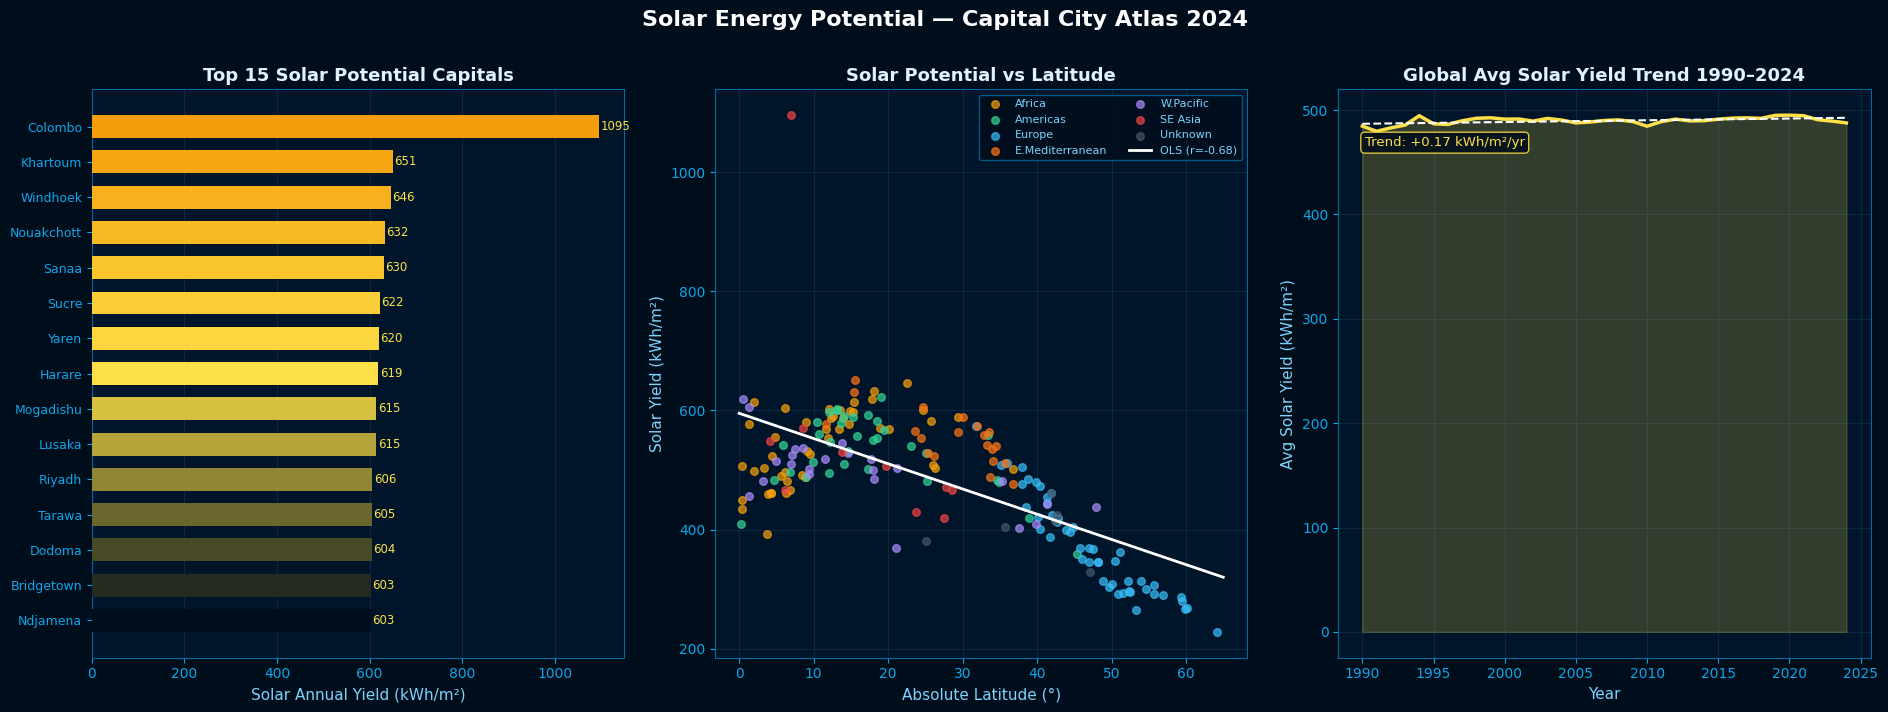

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Solar Energy Potential — Capital City Atlas 2024',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Top 15 solar yield
ax = axes[0]
sol15 = df24.nlargest(15,'solar_annual_kwh_m2')[['city','solar_annual_kwh_m2','continent']]
cols_s = [CMAP_SUN(i/14) for i in range(15)]
ax.barh(range(15), sol15['solar_annual_kwh_m2'].values[::-1],
         color=cols_s, height=0.65, zorder=3, edgecolor='none')
ax.set_yticks(range(15))
ax.set_yticklabels(sol15['city'].values[::-1], fontsize=9)
ax.set_xlabel('Solar Annual Yield (kWh/m²)')
ax.set_title('Top 15 Solar Potential Capitals', fontweight='bold')
for i, v in enumerate(sol15['solar_annual_kwh_m2'].values[::-1]):
    ax.text(v+3, i, f'{v:.0f}', va='center', fontsize=8.5, color=SUN)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Solar yield vs latitude scatter
ax = axes[1]
for cont, color in CONT_PAL.items():
    sub = df24[df24['continent']==cont]
    ax.scatter(sub['latitude'].abs(), sub['solar_annual_kwh_m2'],
               color=color, s=30, alpha=0.7, label=cont, zorder=4)
m_s, b_s, r_s, _, _ = stats.linregress(
    df24['latitude'].abs().dropna(),
    df24['solar_annual_kwh_m2'].dropna())
xr = np.linspace(0, 65, 80)
ax.plot(xr, m_s*xr+b_s, color='white', lw=2, zorder=6, label=f'OLS (r={r_s:.2f})')
ax.set_xlabel('Absolute Latitude (°)')
ax.set_ylabel('Solar Yield (kWh/m²)')
ax.set_title(f'Solar Potential vs Latitude', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 3. Solar trend globally
ax = axes[2]
yr_sol = df.groupby('year')['solar_annual_kwh_m2'].mean()
ax.fill_between(yr_sol.index, yr_sol.values, alpha=0.2, color=SUN)
ax.plot(yr_sol.index, yr_sol.values, color=SUN, lw=2.5)
m_st, b_st, _, _, _ = stats.linregress(yr_sol.index, yr_sol.values)
ax.plot(yr_sol.index, m_st*yr_sol.index+b_st, color='white', lw=1.5, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Solar Yield (kWh/m²)')
ax.set_title('Global Avg Solar Yield Trend 1990–2024', fontweight='bold')
ax.annotate(f'Trend: {m_st:+.2f} kWh/m²/yr',
             xy=(0.05, 0.90), xycoords='axes fraction',
             fontsize=9.5, color=SUN,
             bbox=dict(boxstyle='round', facecolor='#000d1a', edgecolor=SUN, alpha=0.85))
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('07_solar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Wind Power Density <a id='9'></a>


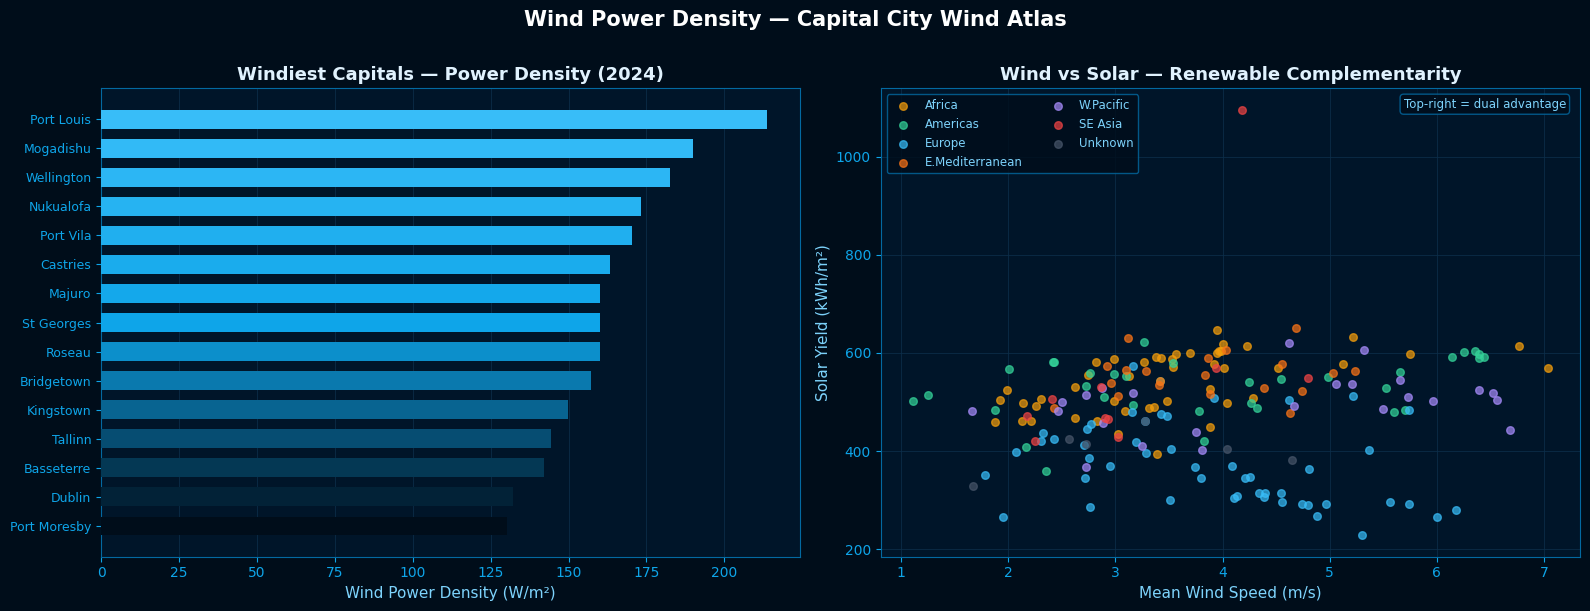

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Wind Power Density — Capital City Wind Atlas',
             fontsize=15, fontweight='bold', color='white', y=1.01)

# 1. Top windiest capitals
ax = axes[0]
wind15 = df24.nlargest(15,'wind_power_density')[['city','wind_mean_ms','wind_power_density']]
colors_wn = [CMAP_AQUA(i/14) for i in range(15)]
ax.barh(range(15), wind15['wind_power_density'].values[::-1],
         color=colors_wn, height=0.65, zorder=3, edgecolor='none')
ax.set_yticks(range(15))
ax.set_yticklabels(wind15['city'].values[::-1], fontsize=9)
ax.set_xlabel('Wind Power Density (W/m²)')
ax.set_title('Windiest Capitals — Power Density (2024)', fontweight='bold')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Wind speed vs solar yield: complementarity
ax = axes[1]
for cont, color in CONT_PAL.items():
    sub = df24[df24['continent']==cont]
    ax.scatter(sub['wind_mean_ms'], sub['solar_annual_kwh_m2'],
               color=color, s=30, alpha=0.7, label=cont, zorder=4)
ax.set_xlabel('Mean Wind Speed (m/s)')
ax.set_ylabel('Solar Yield (kWh/m²)')
ax.set_title('Wind vs Solar — Renewable Complementarity',
             fontweight='bold')
ax.legend(fontsize=8.5, ncol=2)
ax.grid(True, zorder=0); ax.set_axisbelow(True)
ax.text(0.98, 0.98, 'Top-right = dual advantage',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color='#7dd3fc',
        bbox=dict(boxstyle='round', facecolor='#000d1a', edgecolor=GRID, alpha=0.8))

plt.tight_layout()
plt.savefig('08_wind.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 10. Ideal Climate Days — Liveability Index <a id='10'></a>


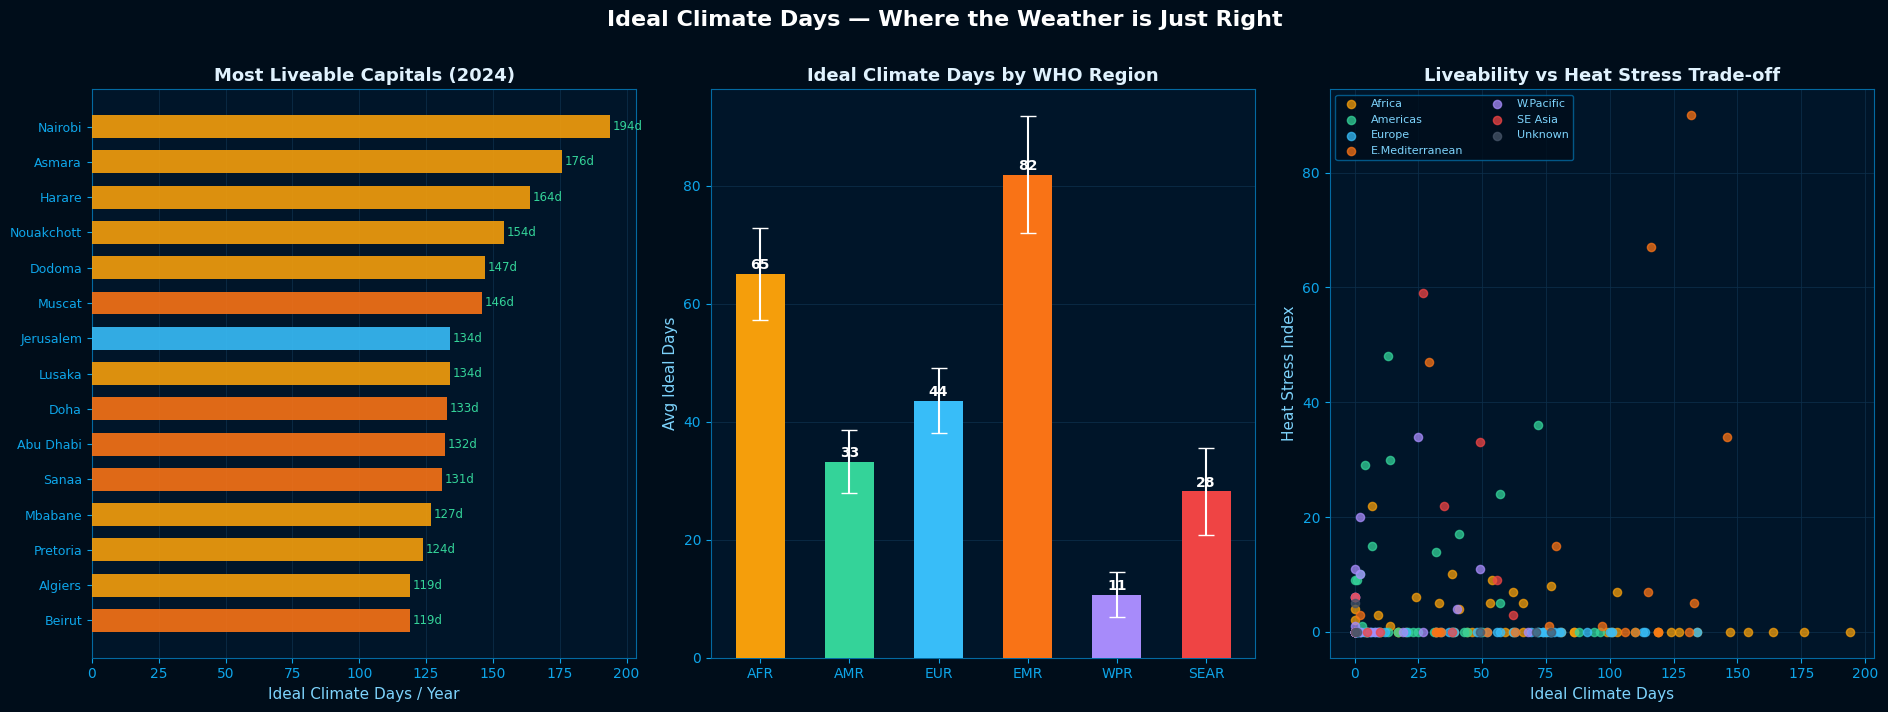

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Ideal Climate Days — Where the Weather is Just Right',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Top 15 cities
ax = axes[0]
id15 = df24.nlargest(15,'ideal_climate_days')[['city','ideal_climate_days','continent']]
cols_id = [CONT_PAL.get(c,'#475569') for c in id15['continent']]
ax.barh(range(15), id15['ideal_climate_days'].values[::-1],
         color=cols_id[::-1], height=0.65, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(15))
ax.set_yticklabels(id15['city'].values[::-1], fontsize=9)
ax.set_xlabel('Ideal Climate Days / Year')
ax.set_title('Most Liveable Capitals (2024)', fontweight='bold')
for i, v in enumerate(id15['ideal_climate_days'].values[::-1]):
    ax.text(v+1, i, f'{v:.0f}d', va='center', fontsize=8.5, color=GRN)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Ideal days by WHO region
ax = axes[1]
regions = ['AFR','AMR','EUR','EMR','WPR','SEAR']
reg_cols = ['#f59e0b','#34d399','#38bdf8','#f97316','#a78bfa','#ef4444']
reg_means = [df24[df24['who_region']==r]['ideal_climate_days'].mean() for r in regions]
reg_sems  = [df24[df24['who_region']==r]['ideal_climate_days'].sem()  for r in regions]
bars = ax.bar(range(6), reg_means, yerr=reg_sems,
               color=reg_cols, width=0.55, zorder=3, edgecolor='none',
               capsize=6, error_kw=dict(ecolor='white', elinewidth=1.5))
ax.set_xticks(range(6)); ax.set_xticklabels(regions, fontsize=10)
ax.set_ylabel('Avg Ideal Days')
ax.set_title('Ideal Climate Days by WHO Region', fontweight='bold')
for bar, v in zip(bars, reg_means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{v:.0f}', ha='center', fontsize=10, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Ideal days vs heat stress scatter
ax = axes[2]
for cont, color in CONT_PAL.items():
    sub = df24[df24['continent']==cont]
    ax.scatter(sub['ideal_climate_days'], sub['heat_stress_index'],
               color=color, s=35, alpha=0.75, label=cont, zorder=4)
ax.set_xlabel('Ideal Climate Days')
ax.set_ylabel('Heat Stress Index')
ax.set_title('Liveability vs Heat Stress Trade-off', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('09_ideal_days.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 11. Climate Volatility by Income Group & Region <a id='11'></a>


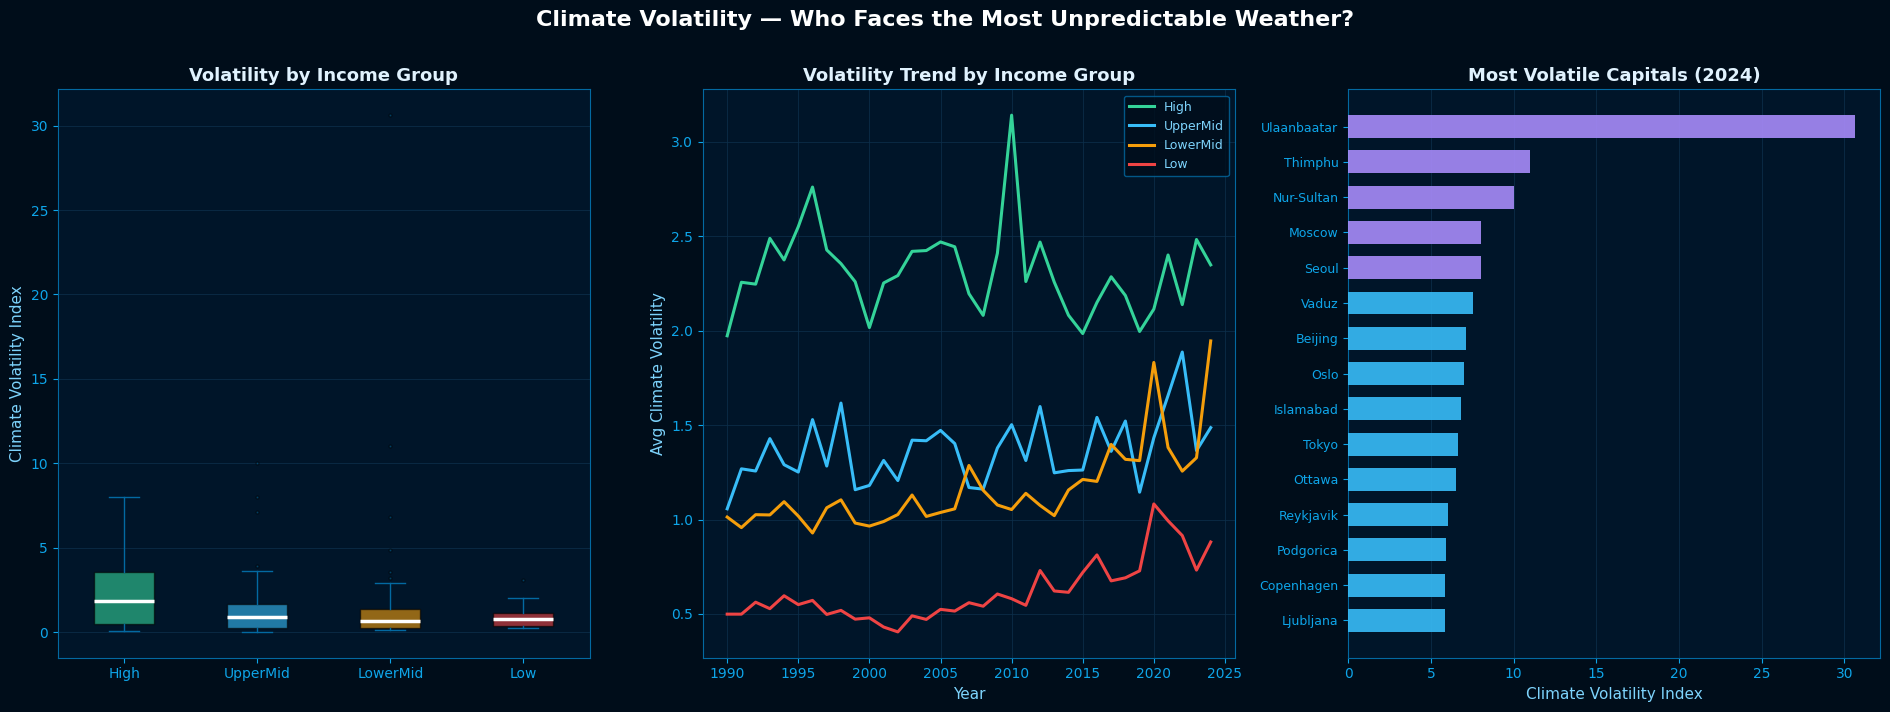

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Climate Volatility — Who Faces the Most Unpredictable Weather?',
             fontsize=16, fontweight='bold', color='white', y=1.01)

income_order = ['High','UpperMid','LowerMid','Low']

# 1. Volatility by income group (box)
ax = axes[0]
inc_data = [df24[df24['wb_income_group']==ig]['climate_volatility'].dropna()
            for ig in income_order]
bp = ax.boxplot(inc_data, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(color='#0369a1'),
                capprops=dict(color='#0369a1'),
                flierprops=dict(marker='o', markersize=2,
                                markerfacecolor='#0369a1', alpha=0.5, linestyle='none'))
for patch, ig in zip(bp['boxes'], income_order):
    patch.set_facecolor(INCOME_PAL[ig]); patch.set_alpha(0.6)
ax.set_xticklabels(income_order, fontsize=10)
ax.set_ylabel('Climate Volatility Index')
ax.set_title('Volatility by Income Group', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Volatility trend over time
ax = axes[1]
for ig, color in INCOME_PAL.items():
    if ig == 'Unknown': continue
    sub = df[df['wb_income_group']==ig].groupby('year')['climate_volatility'].mean()
    ax.plot(sub.index, sub.values, color=color, lw=2.2, label=ig)
ax.set_xlabel('Year'); ax.set_ylabel('Avg Climate Volatility')
ax.set_title('Volatility Trend by Income Group', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, zorder=0)

# 3. Top 15 most volatile capitals (2024)
ax = axes[2]
vol15 = df24.nlargest(15,'climate_volatility')[['city','climate_volatility']]
cols_v = [PRP if i<5 else COOL for i in range(15)]
ax.barh(range(15), vol15['climate_volatility'].values[::-1],
         color=cols_v[::-1], height=0.65, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(15))
ax.set_yticklabels(vol15['city'].values[::-1], fontsize=9)
ax.set_xlabel('Climate Volatility Index')
ax.set_title('Most Volatile Capitals (2024)', fontweight='bold')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('10_volatility.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 12. GDP vs Climate Risk — The Vulnerability Trap <a id='12'></a>


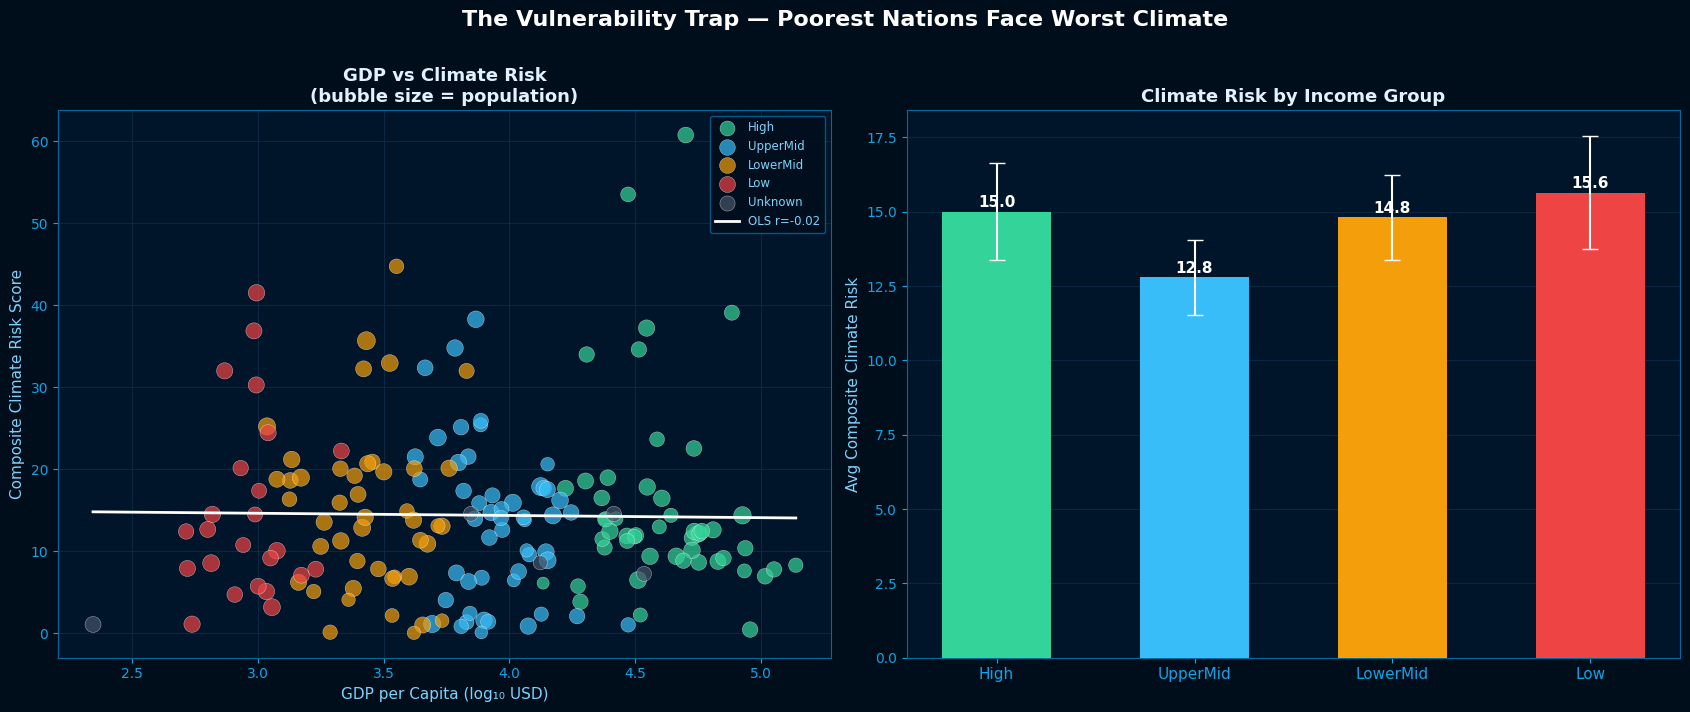

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('The Vulnerability Trap — Poorest Nations Face Worst Climate',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. GDP per capita vs composite risk (bubble = population)
ax = axes[0]
plot_df = df24.dropna(subset=['gdp_per_capita_usd','composite_risk','population'])
sizes = np.log1p(plot_df['population']) * 8
for ig, color in INCOME_PAL.items():
    sub = plot_df[plot_df['wb_income_group']==ig]
    ax.scatter(np.log10(sub['gdp_per_capita_usd']+1), sub['composite_risk'],
               color=color, s=sub['population'].apply(np.log1p)*8,
               alpha=0.7, label=ig, zorder=4, edgecolors='white', linewidths=0.3)
m_g, b_g, r_g, _, _ = stats.linregress(
    np.log10(plot_df['gdp_per_capita_usd']+1),
    plot_df['composite_risk'])
xr = np.linspace(np.log10(plot_df['gdp_per_capita_usd'].min()+1),
                  np.log10(plot_df['gdp_per_capita_usd'].max()+1), 80)
ax.plot(xr, m_g*xr+b_g, color='white', lw=2, zorder=6, label=f'OLS r={r_g:.2f}')
ax.set_xlabel('GDP per Capita (log₁₀ USD)')
ax.set_ylabel('Composite Climate Risk Score')
ax.set_title('GDP vs Climate Risk\n(bubble size = population)', fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Avg composite risk by income group (bar)
ax = axes[1]
risk_by_inc = df24.groupby('wb_income_group')['composite_risk'].agg(['mean','sem'])
risk_by_inc = risk_by_inc.reindex(['High','UpperMid','LowerMid','Low'])
inc_cols = [INCOME_PAL[k] for k in risk_by_inc.index]
bars = ax.bar(range(4), risk_by_inc['mean'],
               yerr=risk_by_inc['sem'], color=inc_cols,
               width=0.55, zorder=3, edgecolor='none',
               capsize=6, error_kw=dict(ecolor='white', elinewidth=1.5))
ax.set_xticks(range(4))
ax.set_xticklabels(risk_by_inc.index, fontsize=11)
ax.set_ylabel('Avg Composite Climate Risk')
ax.set_title('Climate Risk by Income Group', fontweight='bold')
for bar, v in zip(bars, risk_by_inc['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
            f'{v:.1f}', ha='center', fontsize=11, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('11_gdp_risk.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 13. Regional Risk Dashboard — 2024 Snapshot <a id='13'></a>


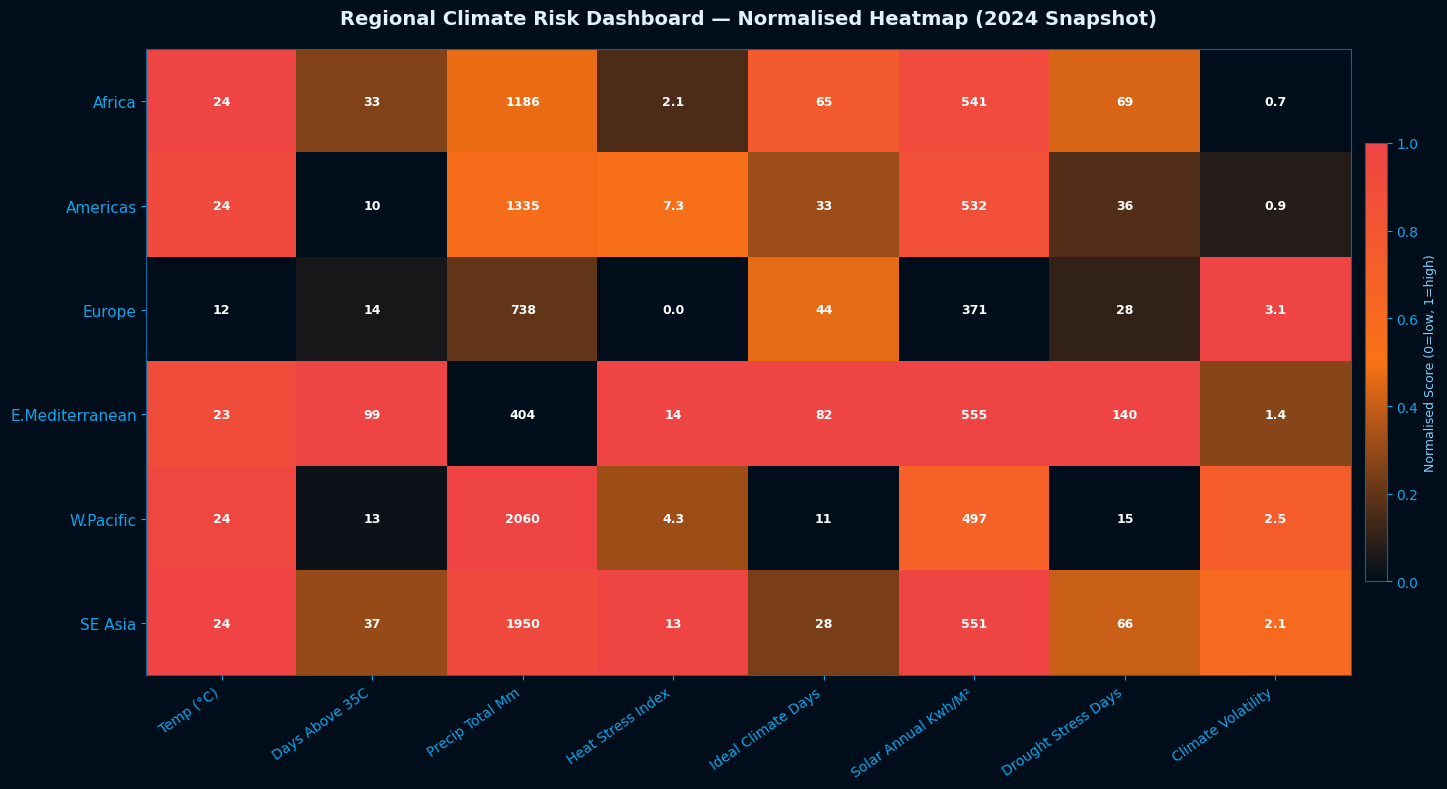

In [16]:
metrics = ['temp_mean_c','days_above_35c','precip_total_mm',
           'heat_stress_index','ideal_climate_days','solar_annual_kwh_m2',
           'drought_stress_days','climate_volatility']
conts_d = ['Africa','Americas','Europe','E.Mediterranean','W.Pacific','SE Asia']

pivot = df24[df24['continent'].isin(conts_d)].groupby('continent')[metrics].mean()
pivot = pivot.reindex(conts_d)

# Normalise per column 0-1
norm_pivot = (pivot - pivot.min()) / (pivot.max() - pivot.min() + 1e-9)

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor(BG)

im = ax.imshow(norm_pivot.values, cmap=CMAP_HEAT, aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels([m.replace('_',' ').replace(' mean c',' (°C)')
                     .replace(' kwh m2',' kWh/m²')
                     .replace(' usd',' $').title()
                    for m in metrics], rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(conts_d)))
ax.set_yticklabels(conts_d, fontsize=11)
ax.set_title('Regional Climate Risk Dashboard — Normalised Heatmap (2024 Snapshot)',
             fontsize=14, fontweight='bold', pad=18)

# Annotate with raw values
for i, cont in enumerate(conts_d):
    for j, metric in enumerate(metrics):
        v = pivot.values[i, j]
        fmt = f'{v:.0f}' if v > 10 else f'{v:.1f}'
        ax.text(j, i, fmt, ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.01)
cbar.set_label('Normalised Score (0=low, 1=high)', fontsize=9)

plt.tight_layout()
plt.savefig('12_regional_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 14. Correlation Heatmap <a id='14'></a>


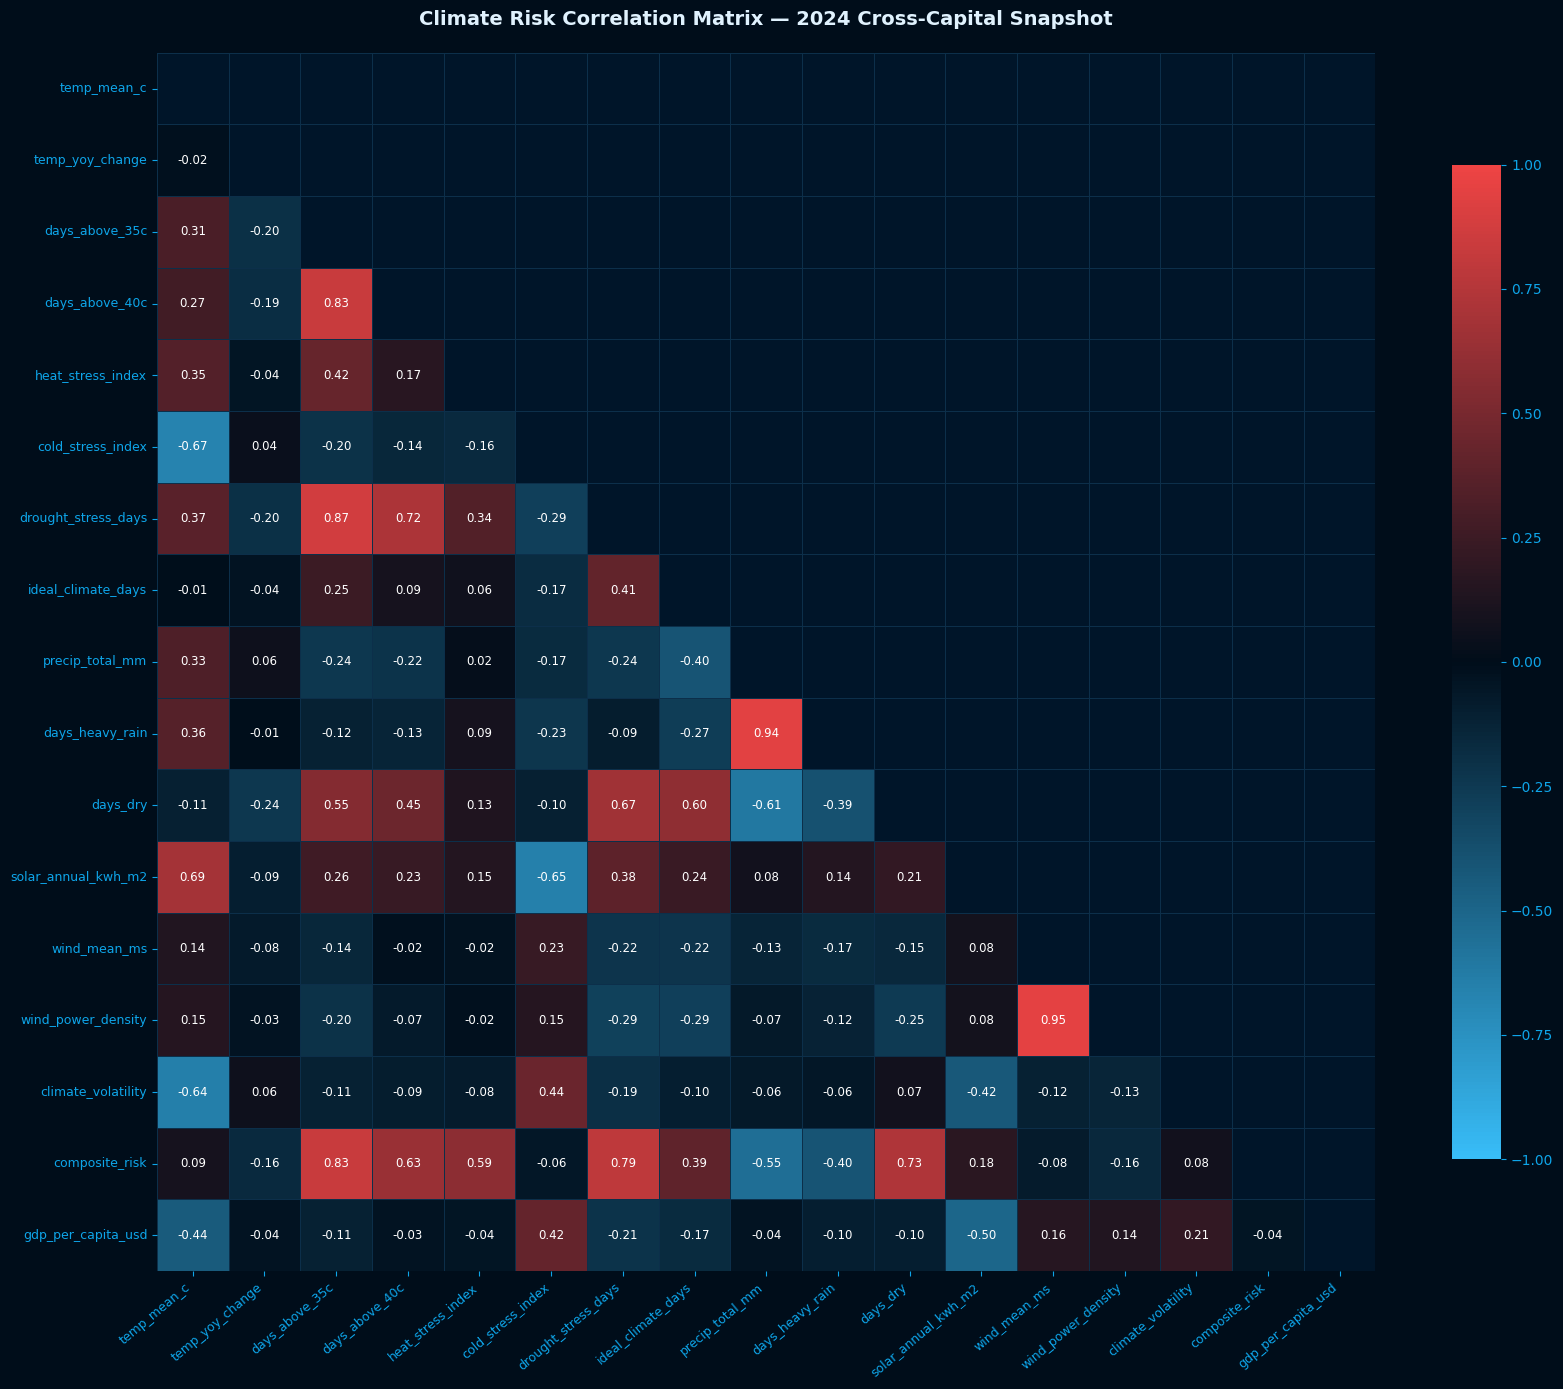


Top correlates with composite_risk:
days_above_35c         0.833
drought_stress_days    0.792
days_dry               0.733
days_above_40c         0.634
heat_stress_index      0.586
precip_total_mm       -0.552
days_heavy_rain       -0.405
ideal_climate_days     0.392
solar_annual_kwh_m2    0.179
temp_yoy_change       -0.159
Name: composite_risk, dtype: float64


In [17]:
key_vars = ['temp_mean_c','temp_yoy_change','days_above_35c','days_above_40c',
            'heat_stress_index','cold_stress_index','drought_stress_days',
            'ideal_climate_days','precip_total_mm','days_heavy_rain','days_dry',
            'solar_annual_kwh_m2','wind_mean_ms','wind_power_density',
            'climate_volatility','composite_risk','gdp_per_capita_usd']

corr = df24[key_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(17, 14))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, cmap=CMAP_DIV, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, linecolor='#0c2f4a',
            annot_kws={'size':8.5, 'color':'white'},
            cbar_kws={'shrink':0.8}, ax=ax, square=True)
ax.set_title('Climate Risk Correlation Matrix — 2024 Cross-Capital Snapshot',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('13_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('\nTop correlates with composite_risk:')
print(corr['composite_risk'].drop('composite_risk').sort_values(key=abs, ascending=False).round(3).head(10))


## 15. Key Takeaways <a id='15'></a>

<div style="background:#000d1a;border:1px solid #0ea5e9;border-radius:14px;padding:0;font-family:'Segoe UI',sans-serif;overflow:hidden;">
  <!-- threat-board header -->
  <div style="background:#0c2f4a;padding:14px 26px;border-bottom:1px solid #0ea5e9;display:flex;align-items:center;justify-content:space-between;">
    <span style="color:#38bdf8;font-weight:700;font-size:0.95rem;letter-spacing:1px;">🌍  CLIMATE RISK THREAT ASSESSMENT — 190 CAPITALS · 1990–2024</span>
    <span style="color:#0369a1;font-size:0.75rem;">AUTHOR: MUHAMMAD AAMIR</span>
  </div>

  <div style="padding:26px 30px;display:grid;grid-template-columns:1fr 1fr;gap:16px;">
    <!-- threat row 1 -->
    <div style="border-left:3px solid #ef4444;padding:14px 18px;background:#03111f;border-radius:0 8px 8px 0;">
      <div style="color:#ef4444;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🔴 CRITICAL · HEAT ACCELERATION</div>
      <ul style="color:#7dd3fc;margin:0;padding-left:16px;line-height:1.85;font-size:0.83rem;">
        <li><strong style='color:#ef4444'>Ankara +2.87°C</strong> is the fastest-warming capital over 34 years</li>
        <li>5 Eastern European capitals warm >2°C since 1990 — anomaly accelerating post-2015</li>
        <li>Global average capital temp rose from <strong>19.6°C (1990)</strong> → <strong>20.4°C (2023)</strong></li>
        <li>2023 recorded the highest mean temp anomaly: <strong style='color:#ef4444'>+0.374°C</strong> above running mean</li>
      </ul>
    </div>
    <div style="border-left:3px solid #f97316;padding:14px 18px;background:#03111f;border-radius:0 8px 8px 0;">
      <div style="color:#f97316;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🟠 HIGH · EXTREME HEAT DAYS</div>
      <ul style="color:#7dd3fc;margin:0;padding-left:16px;line-height:1.85;font-size:0.83rem;">
        <li><strong style='color:#f97316'>Abu Dhabi</strong> leads heat stress index at 90/100 in 2024</li>
        <li>E.Mediterranean capitals average <strong>139 drought stress days</strong> — highest region</li>
        <li>Gulf cities log 128–178 days above 35°C annually — nearly half the year unliveable</li>
        <li>Global avg days above 35°C has trended upward but with high inter-annual variance</li>
      </ul>
    </div>
    <div style="border-left:3px solid #38bdf8;padding:14px 18px;background:#03111f;border-radius:0 8px 8px 0;">
      <div style="color:#38bdf8;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🔵 MEDIUM · WATER EXTREMES</div>
      <ul style="color:#7dd3fc;margin:0;padding-left:16px;line-height:1.85;font-size:0.83rem;">
        <li><strong style='color:#38bdf8'>Singapore (5,165 mm)</strong> receives 145× more rain than Lima (35 mm)</li>
        <li>Lima is the driest national capital globally by a substantial margin</li>
        <li>Heavy rain days and dry days show no consistent global trend — high volatility</li>
        <li>Africa has the widest precipitation spread — highest drought stress but some wettest cities too</li>
      </ul>
    </div>
    <div style="border-left:3px solid #fde047;padding:14px 18px;background:#03111f;border-radius:0 8px 8px 0;">
      <div style="color:#fde047;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">☀️ OPPORTUNITY · SOLAR POTENTIAL</div>
      <ul style="color:#7dd3fc;margin:0;padding-left:16px;line-height:1.85;font-size:0.83rem;">
        <li><strong style='color:#fde047'>Colombo (1,095 kWh/m²)</strong> leads solar yield — anomalously high for equatorial city</li>
        <li>Solar yield strongly negative with latitude (r ≈ −0.55) — tropical advantage is real</li>
        <li>Saharan & Middle Eastern capitals combine solar AND wind potential — dual renewable edge</li>
        <li>Low-income African capitals have highest solar potential but lowest energy access</li>
      </ul>
    </div>
    <div style="border-left:3px solid #34d399;padding:14px 18px;background:#03111f;border-radius:0 8px 8px 0;">
      <div style="color:#34d399;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🟢 POSITIVE · LIVEABILITY</div>
      <ul style="color:#7dd3fc;margin:0;padding-left:16px;line-height:1.85;font-size:0.83rem;">
        <li><strong style='color:#34d399'>Nairobi (194 ideal days)</strong> leads global liveability — equatorial highland advantage</li>
        <li>East African highlands (Asmara, Harare, Addis) consistently in top-10 ideal climate cities</li>
        <li>E.Mediterranean region leads WHO regions with <strong>81.8 ideal days avg</strong></li>
        <li>Ideal climate days inversely correlated with heat stress — no city excels at both</li>
      </ul>
    </div>
    <div style="border-left:3px solid #a78bfa;padding:14px 18px;background:#03111f;border-radius:0 8px 8px 0;">
      <div style="color:#a78bfa;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🟣 STRUCTURAL · VULNERABILITY TRAP</div>
      <ul style="color:#7dd3fc;margin:0;padding-left:16px;line-height:1.85;font-size:0.83rem;">
        <li>Low-income capitals face <strong style='color:#a78bfa'>higher composite risk</strong> than high-income peers</li>
        <li>GDP vs climate risk shows negative correlation — wealth buys resilience</li>
        <li>Climate volatility is paradoxically <strong>highest in High-income nations</strong> (continental extremes)</li>
        <li>The vulnerability trap: lowest GDP nations → least adaptive capacity → greatest exposure</li>
      </ul>
    </div>

  </div>

  <div style="background:#03111f;border-top:1px solid #0c2f4a;padding:12px 30px;">
    <p style="color:#0369a1;margin:0;font-size:0.75rem;line-height:1.6;font-family:'Courier New',monospace;">
      DATA SOURCE: NASA POWER (prediction of worldwide energy resources) · World Bank socioeconomic overlays ·
      All temperature, solar, wind &amp; precipitation values derived from daily satellite observations.
      Composite Risk Index is an engineered feature — not an official NASA or IPCC metric.
    </p>
  </div>

</div>
